In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
batsman = pd.read_csv("ipl_batsman.csv")

bowler = pd.read_csv("ipl_bowler.csv")

matches = pd.read_csv("matches.csv")

In [8]:
print(batsman.head())

   match_id        date player_team               striker  batting_position  \
0    202501  2025-03-22         KKR               de Kock                 1   
1    202501  2025-03-22         KKR                Rahane                 2   
2    202501  2025-03-22         KKR                Narine                 3   
3    202501  2025-03-22         KKR        Venkatesh Iyer                 4   
4    202501  2025-03-22         KKR  Angkrish Raghuvanshi                 5   

   balls_faced  runs_scored  strike_rate  dots  singles  doubles  triples  \
0            5            4    80.000000     4        0        0        0   
1           31           56   180.645161    14        6        1        0   
2           26           44   169.230769    13        4        1        0   
3            7            6    85.714286     4        2        0        0   
4           22           30   136.363636     4       14        1        0   

   fours  fives  sixes dismissal_type  
0      1      0      0

In [9]:
print(bowler.head())

   match_id  innings         bowler  runs_conceded  wickets_taken  \
0    202501        1      Hazlewood             23              2   
1    202501        1  Krunal Pandya             29              3   
2    202501        1    Livingstone             14              0   
3    202501        1   Rasikh Salam             36              1   
4    202501        1  Suyash Sharma             47              1   

   dots_bowled  fours_conceded  sixes_conceded bowling_team opposition_team  \
0           15               3               1          RCB             KKR   
1            8               2               1          RCB             KKR   
2            2               1               0          RCB             KKR   
3            8               3               3          RCB             KKR   
4            8               6               2          RCB             KKR   

   overs_bowled  economy_rate  
0           4.0          5.75  
1           4.0          7.25  
2           2.

In [10]:
print(matches.head())

            date                                          venue team1 team2  \
0  March 22,2025                          Eden Gardens, Kolkata   KKR   RCB   
1  March 23,2025  Rajiv Gandhi International Stadium, Hyderabad   SRH    RR   
2  March 23,2025                MA Chidambaram Stadium, Chennai   CSK    MI   
3  March 24,2025       ACA-VDCA Cricket Stadium, Vishakhapatnam    DC   LSG   
4  March 25,2025               Narendra Modi Stadium, Ahmedabad    GT  PBKS   

    stage match_winner player_of_the_match     margin  
0  League          RCB       Krunal Pandya  7 wickets  
1  League          SRH        Ishan Kishan    44 runs  
2  League          CSK          Noor Ahmad  4 wickets  
3  League           DC     Ashutosh Sharma   1 wicket  
4  League         PBKS        Shreyas Iyer    11 runs  


In [14]:
print(batsman.columns)

Index(['match_id', 'date', 'player_team', 'striker', 'batting_position',
       'balls_faced', 'runs_scored', 'strike_rate', 'dots', 'singles',
       'doubles', 'triples', 'fours', 'fives', 'sixes', 'dismissal_type'],
      dtype='object')


In [15]:
print(matches.columns)

Index(['date', 'venue', 'team1', 'team2', 'stage', 'match_winner',
       'player_of_the_match', 'margin'],
      dtype='object')


In [16]:
print(bowler.columns)

Index(['match_id', 'innings', 'bowler', 'runs_conceded', 'wickets_taken',
       'dots_bowled', 'fours_conceded', 'sixes_conceded', 'bowling_team',
       'opposition_team', 'overs_bowled', 'economy_rate'],
      dtype='object')


In [17]:
print(batsman.shape)

(1127, 16)


In [18]:
print(bowler.shape)

(870, 12)


In [19]:
print(matches.shape)

(74, 8)


In [20]:
print(batsman.isnull().sum())

print(bowler.isnull().sum())

print(matches.isnull().sum())

match_id            0
date                0
player_team         0
striker             0
batting_position    0
balls_faced         0
runs_scored         0
strike_rate         0
dots                0
singles             0
doubles             0
triples             0
fours               0
fives               0
sixes               0
dismissal_type      0
dtype: int64
match_id           0
innings            0
bowler             0
runs_conceded      0
wickets_taken      0
dots_bowled        0
fours_conceded     0
sixes_conceded     0
bowling_team       0
opposition_team    0
overs_bowled       0
economy_rate       0
dtype: int64
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
match_winner           3
player_of_the_match    3
margin                 4
dtype: int64


In [21]:
batsman.drop_duplicates(inplace=True)

bowler.drop_duplicates(inplace=True)

matches.drop_duplicates(inplace=True)

In [40]:
#TOP RUN SCORES

In [23]:
top_runs = (
    batsman.groupby('striker')['runs_scored']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_runs)

striker
Sai Sudharsan       759
Suryakumar Yadav    717
Kohli               657
Shubman Gill        649
Mitchell Marsh      627
Shreyas Iyer        603
Prabhsimran         598
Jaiswal             559
Rahul               546
Priyansh Arya       545
Name: runs_scored, dtype: int64


In [23]:

top_runs = (
    batsman.groupby('striker')['runs_scored']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_runs)

striker
Sai Sudharsan       759
Suryakumar Yadav    717
Kohli               657
Shubman Gill        649
Mitchell Marsh      627
Shreyas Iyer        603
Prabhsimran         598
Jaiswal             559
Rahul               546
Priyansh Arya       545
Name: runs_scored, dtype: int64


In [ ]:
# TOP WICKET TAKERS

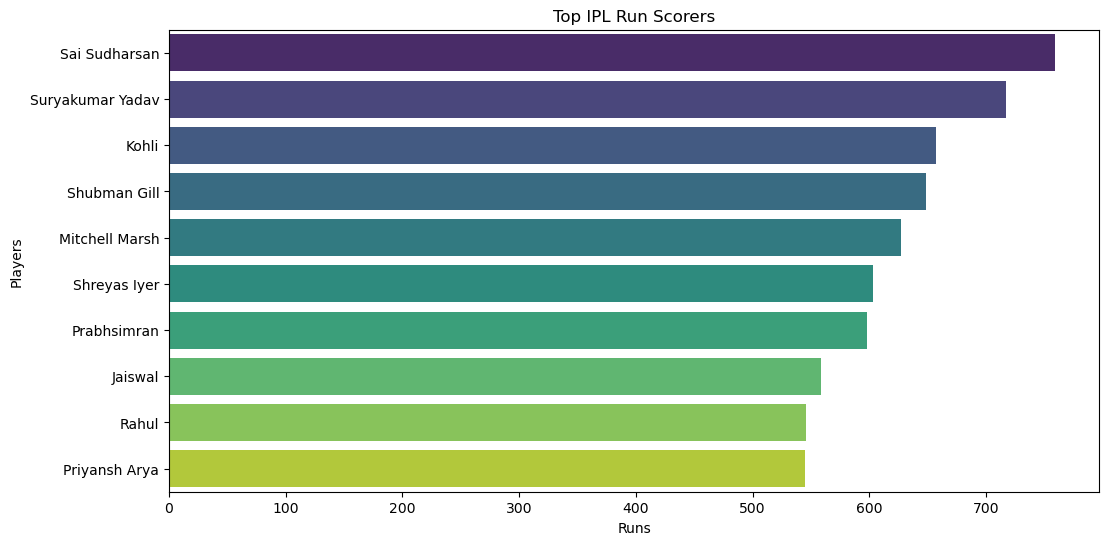

In [77]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_runs.values,
    y=top_runs.index,
    hue= top_runs.index,
    palette='viridis',
    legend='auto'
)

plt.title("Top IPL Run Scorers")

plt.xlabel("Runs")

plt.ylabel("Players")

plt.show()

<Axes: xlabel='striker', ylabel='runs_scored'>

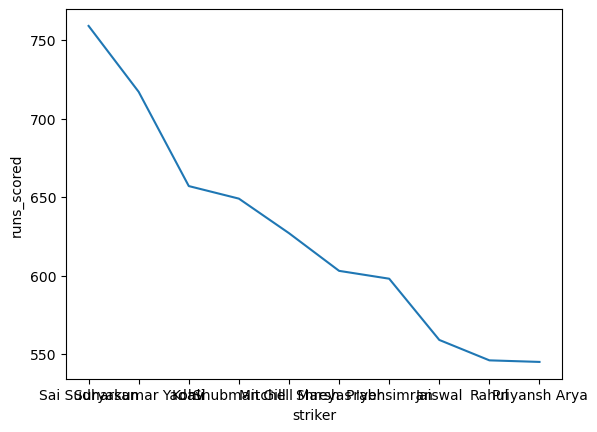

In [33]:
sns.lineplot(top_runs)

In [35]:
top_wickets = (
    bowler.groupby('bowler')['wickets_taken']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_wickets)

bowler
Prasidh           26
Noor Ahmad        24
Boult             23
Hazlewood         22
Arshdeep Singh    22
Bumrah            21
Sai Kishore       19
Mitchell Starc    19
Vaibhav Arora     19
Bhuvneshwar       18
Name: wickets_taken, dtype: int64


In [ ]:
#BEST ECONOMY RATE

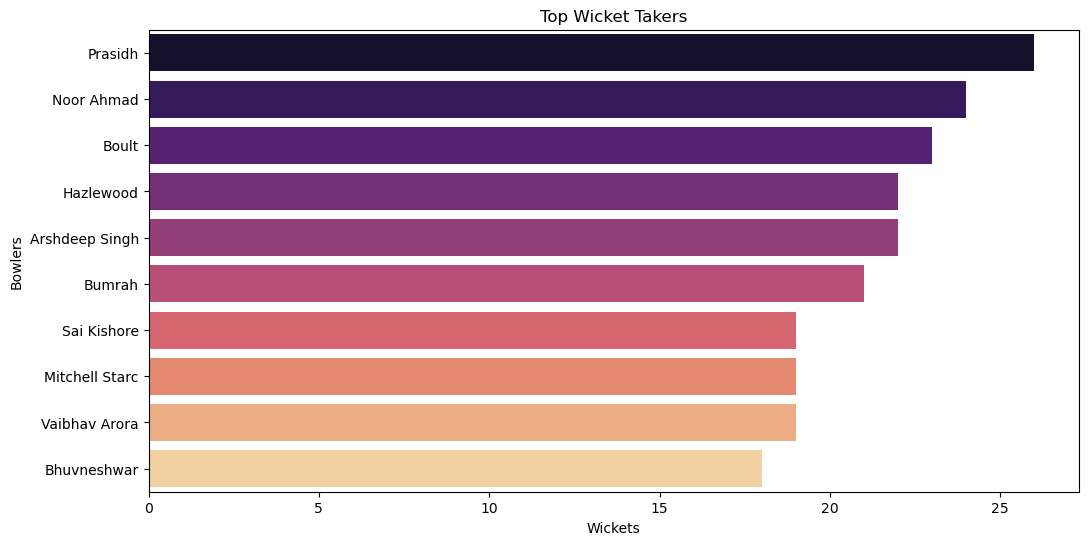

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_wickets.values,
    y=top_wickets.index,
    hue= top_wickets.index,
    palette='magma',
    legend='auto'
)

plt.title("Top Wicket Takers")

plt.xlabel("Wickets")

plt.ylabel("Bowlers")

plt.show()

In [44]:
best_economy = (
    bowler.groupby('bowler')['economy_rate']
    .mean()
    .sort_values()
    .head(10)
)

print(best_economy)

bowler
Naman Dhir             6.500000
Anukul Roy             6.750000
Bumrah                 6.758333
Unadkat                7.499300
N Thushara             7.500000
Kuldeep Yadav          7.678571
Mustafizur             7.916667
Varun Chakaravarthy    7.923077
Narine                 8.027778
Maxwell                8.027778
Name: economy_rate, dtype: float64


In [62]:
#MOST SUCCESSFUL TEAMS

In [46]:
team_wins = matches['match_winner'].value_counts()

print(team_wins)

match_winner
PBKS    11
RCB     10
GT       9
DC       8
MI       8
SRH      6
LSG      6
KKR      5
CSK      4
RR       4
Name: count, dtype: int64


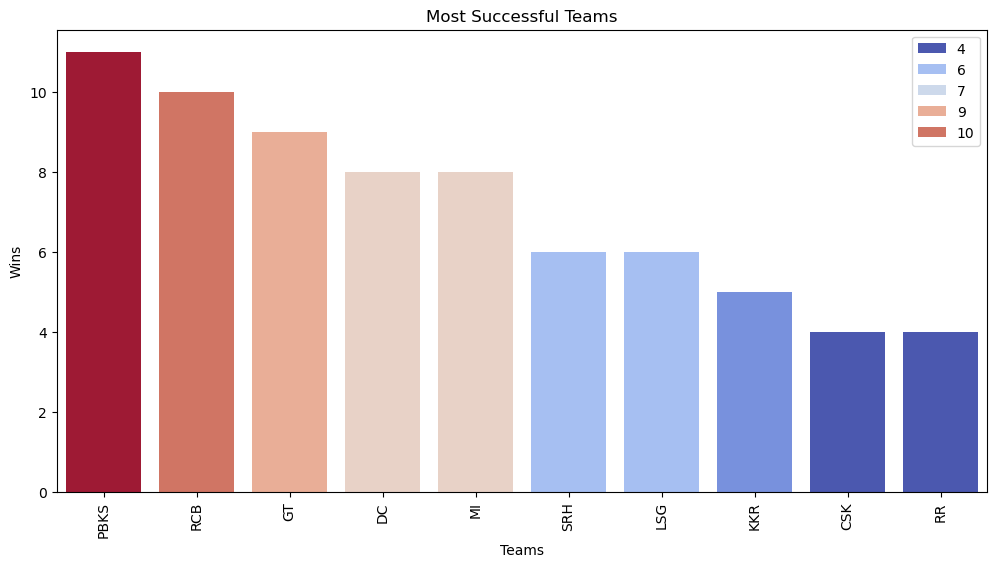

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=team_wins.index,
    y=team_wins.values,
    hue= team_wins.values,
    palette='coolwarm',
    legend='auto'
)

plt.xticks(rotation=90)

plt.title("Most Successful Teams")

plt.xlabel("Teams")

plt.ylabel("Wins")

plt.show()

In [63]:
# TOP IPL VENUES

In [50]:
venue_stats = matches['venue'].value_counts()

print(venue_stats.head(10))

venue
Narendra Modi Stadium, Ahmedabad                 9
Ekana Cricket Stadium, Lucknow                   8
Eden Gardens, Kolkata                            7
Wankhede Stadium, Mumbai                         7
Sawai Mansingh Stadium, Jaipur                   7
Arun Jaitley Stadium, Delhi                      7
Rajiv Gandhi International Stadium, Hyderabad    6
MA Chidambaram Stadium, Chennai                  6
M. Chinnaswamy Stadium, Bangalore                6
New PCA Cricket Stadium, Mullanpur               6
Name: count, dtype: int64


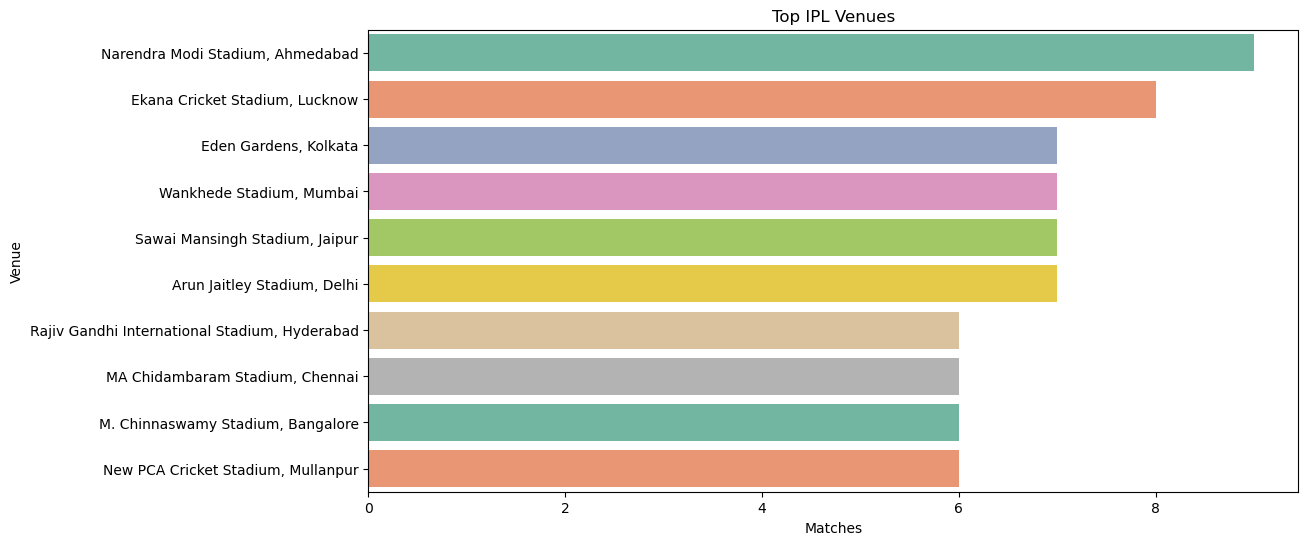

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=venue_stats.values[:10],
    y=venue_stats.index[:10],
    hue=venue_stats.index[:10],
    palette='Set2',
    legend= 'auto'
)

plt.title("Top IPL Venues")

plt.xlabel("Matches")

plt.ylabel("Venue")

plt.show()

In [76]:
#TOP DOT BALL BOWLERS

In [64]:
dots = (
    bowler.groupby('bowler')['dots_bowled']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(dots)

bowler
Siraj                  141
Prasidh                135
Arshdeep Singh         134
Khaleel Ahmed          131
Bumrah                 125
Boult                  124
Hazlewood              117
Bhuvneshwar            116
Varun Chakaravarthy    114
Cummins                111
Name: dots_bowled, dtype: int64


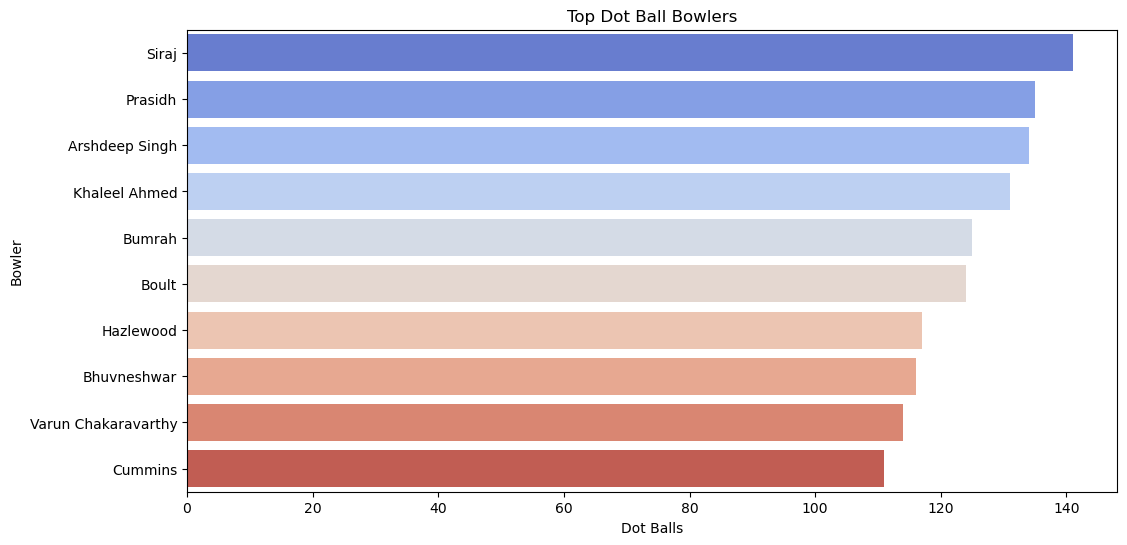

In [75]:
dots = dots.reset_index(drop = True)

plt.figure(figsize=(12,6))

sns.barplot(
    data=dots,
    x='dots_bowled',
    y='bowler',
    hue='bowler',
    palette='coolwarm',
    legend= 'auto'
)

plt.title("Top Dot Ball Bowlers")
plt.xlabel("Dot Balls")
plt.ylabel("Bowler")

plt.show()